In [1]:
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

from PIL import Image, ImageDraw, ImageFont
from azure.ai.vision.imageanalysis import ImageAnalysisClient
from azure.ai.vision.imageanalysis.models import VisualFeatures
from azure.core.credentials import AzureKeyCredential


In [2]:
def set_matplotlib_korean_font():
    """
    Jupyter / matplotlib에서 한글이 깨지지 않도록 폰트를 설정합니다.
    """
    system_name = platform.system()

    if system_name == "Darwin":  # macOS
        plt.rcParams["font.family"] = "AppleGothic"
    elif system_name == "Windows":
        plt.rcParams["font.family"] = "Malgun Gothic"
    else:  # Linux / Colab
        plt.rcParams["font.family"] = "NanumGothic"

    # 마이너스 기호 깨짐 방지
    plt.rcParams["axes.unicode_minus"] = False

In [3]:
set_matplotlib_korean_font()

In [4]:
# 설정값
PERSON_CONFIDENCE_THRESHOLD = 0.5
PERSON_NMS_IOU_THRESHOLD = 0.5

IMAGE_PATH = "teamroom.jpg"

RAW_OUTPUT_IMAGE_PATH = "raw_result.jpg"
FILTERED_OUTPUT_IMAGE_PATH = "filtered_result.jpg"
FINAL_OUTPUT_IMAGE_PATH = "final_result.jpg"

PERSONAL_OBJECT_KEYWORDS = {
    "laptop",
    "backpack",
    "bag",
    "bags",
    "book",
    "chair",
    "table",
    "luggage",
    "bear"
}

In [5]:
# Bounding Box 정규화
def normalize_bounding_box(bounding_box):
    """Azure SDK bounding_box 값을 {'x', 'y', 'w', 'h'} dict 형태로 통일합니다."""
    if isinstance(bounding_box, dict):
        return {
            "x": int(bounding_box["x"]),
            "y": int(bounding_box["y"]),
            "w": int(bounding_box["w"]),
            "h": int(bounding_box["h"]),
        }

    width = getattr(bounding_box, "w", None)
    if width is None:
        width = getattr(bounding_box, "width")

    height = getattr(bounding_box, "h", None)
    if height is None:
        height = getattr(bounding_box, "height")

    return {
        "x": int(bounding_box.x),
        "y": int(bounding_box.y),
        "w": int(width),
        "h": int(height),
    }

In [6]:
def calculate_iou(box_a, box_b):
    """두 bounding box의 IoU(Intersection over Union)를 계산합니다."""
    a = normalize_bounding_box(box_a)
    b = normalize_bounding_box(box_b)

    a_x2 = a["x"] + a["w"]
    a_y2 = a["y"] + a["h"]
    b_x2 = b["x"] + b["w"]
    b_y2 = b["y"] + b["h"]

    intersection_x1 = max(a["x"], b["x"])
    intersection_y1 = max(a["y"], b["y"])
    intersection_x2 = min(a_x2, b_x2)
    intersection_y2 = min(a_y2, b_y2)

    intersection_width = max(0, intersection_x2 - intersection_x1)
    intersection_height = max(0, intersection_y2 - intersection_y1)
    intersection_area = intersection_width * intersection_height

    area_a = a["w"] * a["h"]
    area_b = b["w"] * b["h"]
    union_area = area_a + area_b - intersection_area

    if union_area == 0:
        return 0.0

    return intersection_area / union_area

In [7]:
def decide_room_status(people_count, relevant_objects):
    """필터링된 사람 수와 관련 객체 감지 결과를 이용해 최종 방 상태를 판단합니다."""
    if people_count >= 1:
        return "사용 중"

    if relevant_objects:
        return "일시 자리 비움 가능성"

    return "비어 있음"


def load_korean_font(size=24):
    """
    macOS / Windows / Linux 환경에서 한글을 지원하는 폰트를 찾습니다.
    찾지 못하면 기본 폰트를 사용합니다.
    """
    font_candidates = [
        # macOS
        "/System/Library/Fonts/AppleSDGothicNeo.ttc",
        "/System/Library/Fonts/Supplemental/AppleGothic.ttf",

        # Windows
        "C:/Windows/Fonts/malgun.ttf",

        # Linux
        "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
    ]

    for font_path in font_candidates:
        if os.path.exists(font_path):
            return ImageFont.truetype(font_path, size)

    return ImageFont.load_default()


def get_text_size(draw, text, font):
    """
    Pillow 버전에 따라 textbbox 또는 textsize를 사용해 텍스트 크기를 구합니다.
    """
    if hasattr(draw, "textbbox"):
        bbox = draw.textbbox((0, 0), text, font=font)
        width = bbox[2] - bbox[0]
        height = bbox[3] - bbox[1]
        return width, height

    return draw.textsize(text, font=font)

In [8]:
# People / Object 처리
def filter_people_detections(
    people,
    confidence_threshold=PERSON_CONFIDENCE_THRESHOLD,
    iou_threshold=PERSON_NMS_IOU_THRESHOLD,
):
    """
    People Detection 결과를 confidence threshold와 IoU 기반 NMS로 후처리합니다.
    """
    if people is None:
        return []

    confident_people = [
        person
        for person in people
        if person.confidence is not None and person.confidence >= confidence_threshold
    ]

    sorted_people = sorted(
        confident_people,
        key=lambda person: person.confidence,
        reverse=True,
    )

    selected_people = []
    for candidate in sorted_people:
        is_duplicate = any(
            calculate_iou(candidate.bounding_box, selected.bounding_box) >= iou_threshold
            for selected in selected_people
        )

        if not is_duplicate:
            selected_people.append(candidate)

    return selected_people


def get_object_name_and_confidence(detected_object):
    """Azure Object Detection 결과에서 대표 tag 이름과 confidence를 꺼냅니다."""
    if not detected_object.tags:
        return None, None

    primary_tag = detected_object.tags[0]
    return primary_tag.name, primary_tag.confidence


def is_personal_object(object_name):
    """객체명이 개인 물건/좌석 관련 키워드를 포함하는지 확인합니다."""
    if object_name is None:
        return False

    normalized_name = object_name.lower()
    return any(keyword in normalized_name for keyword in PERSONAL_OBJECT_KEYWORDS)


def filter_relevant_objects(objects):
    """방 상태 판단에 사용할 주요 객체만 추려냅니다."""
    if objects is None:
        return []

    relevant_objects = []
    for detected_object in objects:
        object_name, confidence = get_object_name_and_confidence(detected_object)

        if is_personal_object(object_name):
            relevant_objects.append(
                {
                    "name": object_name,
                    "confidence": confidence,
                    "bounding_box": normalize_bounding_box(detected_object.bounding_box),
                }
            )

    return relevant_objects


def convert_people_to_drawable_list(people):
    """
    필터링 전 people 결과도 draw_bounding_boxes에서 바로 사용할 수 있도록 반환합니다.
    """
    if people is None:
        return []

    return [
        person
        for person in people
        if person.confidence is not None
    ]


def convert_objects_to_drawable_list(objects):
    """
    필터링 전 object 결과를 이미지에 그릴 수 있는 dict 형태로 변환합니다.
    """
    if objects is None:
        return []

    drawable_objects = []

    for detected_object in objects:
        object_name, confidence = get_object_name_and_confidence(detected_object)

        if object_name is None or confidence is None:
            continue

        drawable_objects.append(
            {
                "name": object_name,
                "confidence": confidence,
                "bounding_box": normalize_bounding_box(detected_object.bounding_box),
            }
        )

    return drawable_objects



In [9]:
# Azure 분석
def analyze_image():
    """
    Azure Vision 분석만 수행하고 result를 반환합니다.
    """
    try:
        endpoint = os.environ["VISION_ENDPOINT"]
        key = os.environ["VISION_KEY"]
    except KeyError:
        print("Missing environment variable 'VISION_ENDPOINT' or 'VISION_KEY'")
        print("Set them before running this sample.")
        raise

    client = ImageAnalysisClient(
        endpoint=endpoint,
        credential=AzureKeyCredential(key),
    )

    with open(IMAGE_PATH, "rb") as f:
        image_data = f.read()

    result = client.analyze(
        image_data=image_data,
        visual_features=[VisualFeatures.PEOPLE, VisualFeatures.OBJECTS],
    )

    return result

In [17]:
def draw_bounding_boxes(
    image_path,
    output_path,
    people_to_draw,
    objects_to_draw,
    room_status=None,
    show_status=True,
):
    """
    사람 bbox와 객체 bbox를 이미지 위에 그린 뒤 저장합니다.

    - 사람: 빨간색 박스
    - 객체: 파란색 박스
    - 최종 방 상태: 좌측 상단에 표시
    """

    image = Image.open(image_path).convert("RGB")
    draw = ImageDraw.Draw(image)

    # 상단 박스 크기 줄인 버전
    status_font = load_korean_font(30)
    small_font = load_korean_font(24)

    # 사람 박스
    for index, person in enumerate(people_to_draw, start=1):
        bbox = normalize_bounding_box(person.bounding_box)

        x1 = bbox["x"]
        y1 = bbox["y"]
        x2 = bbox["x"] + bbox["w"]
        y2 = bbox["y"] + bbox["h"]

        label = f"사람 {index} ({person.confidence:.2f})"

        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline="red",
            width=3,
        )

        label_width, label_height = get_text_size(draw, label, small_font)

        label_bg_y1 = max(0, y1 - label_height - 6)
        label_bg_y2 = label_bg_y1 + label_height + 4

        draw.rectangle(
            [(x1, label_bg_y1), (x1 + label_width + 8, label_bg_y2)],
            fill="white",
        )

        draw.text(
            (x1 + 4, label_bg_y1 + 2),
            label,
            fill="red",
            font=small_font,
        )

    # 객체 박스
    for detected_object in objects_to_draw:
        bbox = detected_object["bounding_box"]

        x1 = bbox["x"]
        y1 = bbox["y"]
        x2 = bbox["x"] + bbox["w"]
        y2 = bbox["y"] + bbox["h"]

        label = f"{detected_object['name']} ({detected_object['confidence']:.2f})"

        draw.rectangle(
            [(x1, y1), (x2, y2)],
            outline="blue",
            width=2,
        )

        label_width, label_height = get_text_size(draw, label, small_font)

        label_bg_y1 = max(0, y1 - label_height - 6)
        label_bg_y2 = label_bg_y1 + label_height + 4

        draw.rectangle(
            [(x1, label_bg_y1), (x1 + label_width + 8, label_bg_y2)],
            fill="white",
        )

        draw.text(
            (x1 + 4, label_bg_y1 + 2),
            label,
            fill="blue",
            font=small_font,
        )

    # 방 상태 박스
    if show_status and room_status is not None:
        status_label = f"공간 상태: {room_status}"
        status_width, status_height = get_text_size(draw, status_label, status_font)

        padding_x = 8
        padding_y = 5

        box_x1 = 8
        box_y1 = 8
        box_x2 = box_x1 + status_width + padding_x * 2
        box_y2 = box_y1 + status_height + padding_y * 2

        draw.rectangle(
            [(box_x1, box_y1), (box_x2, box_y2)],
            fill="white",
            outline="black",
            width=1,
        )

        draw.text(
            (box_x1 + padding_x, box_y1 + padding_y),
            status_label,
            fill="black",
            font=status_font,
        )

    image.save(output_path)
    print(f"Saved: {output_path}")

In [18]:
# 단계별 결과 구성
def build_stage_results(result):
    """
    Azure Vision 분석 결과를 바탕으로
    1) 필터링 전
    2) 필터링 후
    3) 최종 결과
    단계별 dictionary를 구성합니다.
    """

    raw_people = result.people.list if result.people is not None else []
    raw_objects_all = result.objects.list if result.objects is not None else []

    # 필터링 전
    raw_people_drawable = convert_people_to_drawable_list(raw_people)
    raw_objects_drawable = convert_objects_to_drawable_list(raw_objects_all)

    # 필터링 후
    filtered_people = filter_people_detections(
        raw_people,
        confidence_threshold=PERSON_CONFIDENCE_THRESHOLD,
        iou_threshold=PERSON_NMS_IOU_THRESHOLD,
    )

    relevant_objects = filter_relevant_objects(raw_objects_all)

    # 최종 판단
    final_people_count = len(filtered_people)
    room_status = decide_room_status(final_people_count, relevant_objects)

    stage_results = {
        "before_filter": {
            "title": "필터링 전",
            "output_path": RAW_OUTPUT_IMAGE_PATH,
            "people": raw_people_drawable,
            "objects": raw_objects_drawable,
            "people_count": len(raw_people_drawable),
            "object_count": len(raw_objects_drawable),
            "room_status": None,
            "show_status": False,
        },
        "after_filter": {
            "title": "필터링 후",
            "output_path": FILTERED_OUTPUT_IMAGE_PATH,
            "people": filtered_people,
            "objects": relevant_objects,
            "people_count": len(filtered_people),
            "object_count": len(relevant_objects),
            "room_status": None,
            "show_status": False,
        },
        "final": {
            "title": "최종 결과",
            "output_path": FINAL_OUTPUT_IMAGE_PATH,
            "people": filtered_people,
            "objects": relevant_objects,
            "people_count": len(filtered_people),
            "object_count": len(relevant_objects),
            "room_status": room_status,
            "show_status": True,
        },
    }

    return stage_results

In [19]:
# 이미지 생성
def generate_stage_images(image_path, stage_results):
    """
    각 단계별 이미지를 생성합니다.
    """
    for stage in stage_results.values():
        draw_bounding_boxes(
            image_path=image_path,
            output_path=stage["output_path"],
            people_to_draw=stage["people"],
            objects_to_draw=stage["objects"],
            room_status=stage["room_status"],
            show_status=stage["show_status"],
        )

    print("All stage images created.")
# 단계별 값 출력
def print_stage_values(stage):
    """
    각 단계에 해당하는 수치/감지값을 출력합니다.
    """
    print("=" * 60)
    print(f"[{stage['title']}]")
    print(f"People count: {stage['people_count']}")
    print(f"Object count: {stage['object_count']}")
    print()

    print("People:")
    if not stage["people"]:
        print("  No people detected.")
    else:
        for index, person in enumerate(stage["people"], start=1):
            bbox = normalize_bounding_box(person.bounding_box)
            print(f"  Person {index}: bbox={bbox}, confidence={person.confidence:.4f}")

    print()
    print("Objects:")
    if not stage["objects"]:
        print("  No objects detected.")
    else:
        for detected_object in stage["objects"]:
            print(
                f"  {detected_object['name']}: "
                f"bbox={detected_object['bounding_box']}, "
                f"confidence={detected_object['confidence']:.4f}"
            )

    if stage["room_status"] is not None:
        print()
        print(f"Room status: {stage['room_status']}")


def print_result_metadata(result):
    """
    공통 메타데이터를 출력합니다.
    """
    print("=" * 60)
    print("[분석 메타데이터]")

    if result.metadata is not None:
        print(f"Image height: {result.metadata.height}")
        print(f"Image width: {result.metadata.width}")

    print(f"Model version: {result.model_version}")


# 이미지 출력
def show_stage_image(stage):
    """
    한 단계의 이미지를 출력합니다.
    """
    image = Image.open(stage["output_path"]).convert("RGB")

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.title(stage["title"], fontsize=14)
    plt.axis("off")
    plt.show()


def show_stage_result(stage):
    """
    한 단계의 값 + 이미지 를 함께 보여줍니다.
    """
    print_stage_values(stage)
    show_stage_image(stage)


def show_all_stage_results(stage_results):
    """
    필터링 전 / 필터링 후 / 최종 결과
    세 단계를 순서대로 값 + 이미지 형태로 보여줍니다.
    """
    show_stage_result(stage_results["before_filter"])
    show_stage_result(stage_results["after_filter"])
    show_stage_result(stage_results["final"])

In [20]:
result = analyze_image()
print("Image analysis completed.")

Image analysis completed.


In [21]:
stage_results = build_stage_results(result)
print("Stage results prepared.")

Stage results prepared.


In [22]:
generate_stage_images(IMAGE_PATH, stage_results)

Saved: teamroom_raw_result.jpg
Saved: teamroom_filtered_result.jpg
Saved: teamroom_final_result.jpg
All stage images created.


[필터링 전]
People count: 15
Object count: 9

People:
  Person 1: bbox={'x': 857, 'y': 463, 'w': 396, 'h': 621}, confidence=0.9385
  Person 2: bbox={'x': 667, 'y': 364, 'w': 182, 'h': 156}, confidence=0.9094
  Person 3: bbox={'x': 148, 'y': 438, 'w': 349, 'h': 508}, confidence=0.9040
  Person 4: bbox={'x': 1173, 'y': 415, 'w': 189, 'h': 374}, confidence=0.9022
  Person 5: bbox={'x': 477, 'y': 352, 'w': 146, 'h': 215}, confidence=0.8992
  Person 6: bbox={'x': 833, 'y': 359, 'w': 177, 'h': 199}, confidence=0.8748
  Person 7: bbox={'x': 467, 'y': 470, 'w': 350, 'h': 355}, confidence=0.8722
  Person 8: bbox={'x': 997, 'y': 386, 'w': 143, 'h': 198}, confidence=0.8442
  Person 9: bbox={'x': 351, 'y': 375, 'w': 211, 'h': 278}, confidence=0.8355
  Person 10: bbox={'x': 900, 'y': 389, 'w': 240, 'h': 420}, confidence=0.0253
  Person 11: bbox={'x': 0, 'y': 324, 'w': 23, 'h': 139}, confidence=0.0037
  Person 12: bbox={'x': 389, 'y': 327, 'w': 398, 'h': 338}, confidence=0.0019
  Person 13: bbox={'x': 8

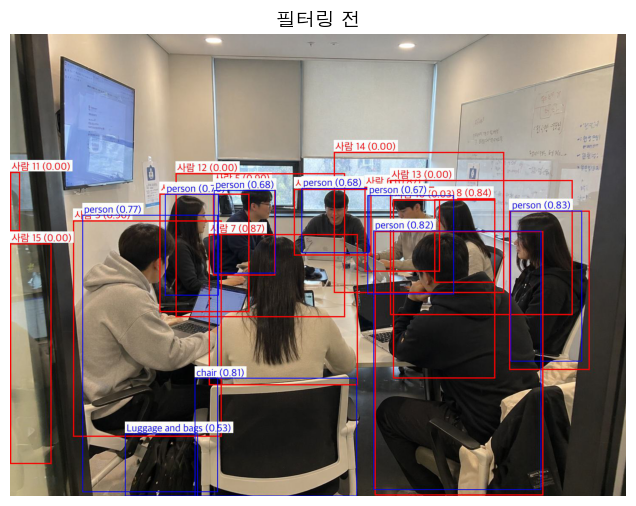

[필터링 후]
People count: 9
Object count: 2

People:
  Person 1: bbox={'x': 857, 'y': 463, 'w': 396, 'h': 621}, confidence=0.9385
  Person 2: bbox={'x': 667, 'y': 364, 'w': 182, 'h': 156}, confidence=0.9094
  Person 3: bbox={'x': 148, 'y': 438, 'w': 349, 'h': 508}, confidence=0.9040
  Person 4: bbox={'x': 1173, 'y': 415, 'w': 189, 'h': 374}, confidence=0.9022
  Person 5: bbox={'x': 477, 'y': 352, 'w': 146, 'h': 215}, confidence=0.8992
  Person 6: bbox={'x': 833, 'y': 359, 'w': 177, 'h': 199}, confidence=0.8748
  Person 7: bbox={'x': 467, 'y': 470, 'w': 350, 'h': 355}, confidence=0.8722
  Person 8: bbox={'x': 997, 'y': 386, 'w': 143, 'h': 198}, confidence=0.8442
  Person 9: bbox={'x': 351, 'y': 375, 'w': 211, 'h': 278}, confidence=0.8355

Objects:
  Luggage and bags: bbox={'x': 270, 'y': 939, 'w': 171, 'h': 147}, confidence=0.5340
  chair: bbox={'x': 434, 'y': 808, 'w': 381, 'h': 278}, confidence=0.8070


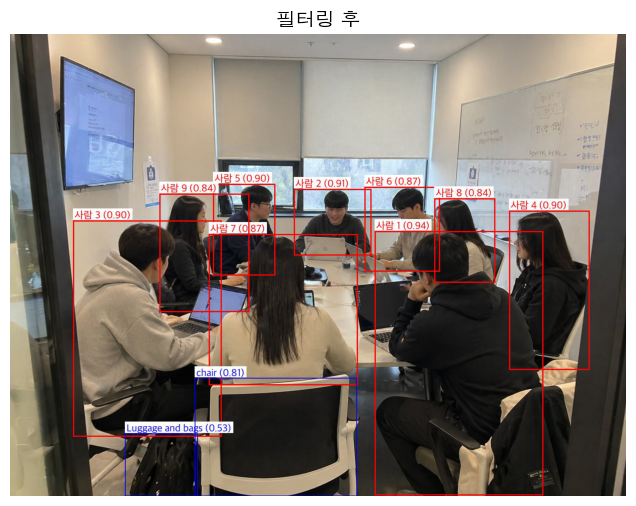

[최종 결과]
People count: 9
Object count: 2

People:
  Person 1: bbox={'x': 857, 'y': 463, 'w': 396, 'h': 621}, confidence=0.9385
  Person 2: bbox={'x': 667, 'y': 364, 'w': 182, 'h': 156}, confidence=0.9094
  Person 3: bbox={'x': 148, 'y': 438, 'w': 349, 'h': 508}, confidence=0.9040
  Person 4: bbox={'x': 1173, 'y': 415, 'w': 189, 'h': 374}, confidence=0.9022
  Person 5: bbox={'x': 477, 'y': 352, 'w': 146, 'h': 215}, confidence=0.8992
  Person 6: bbox={'x': 833, 'y': 359, 'w': 177, 'h': 199}, confidence=0.8748
  Person 7: bbox={'x': 467, 'y': 470, 'w': 350, 'h': 355}, confidence=0.8722
  Person 8: bbox={'x': 997, 'y': 386, 'w': 143, 'h': 198}, confidence=0.8442
  Person 9: bbox={'x': 351, 'y': 375, 'w': 211, 'h': 278}, confidence=0.8355

Objects:
  Luggage and bags: bbox={'x': 270, 'y': 939, 'w': 171, 'h': 147}, confidence=0.5340
  chair: bbox={'x': 434, 'y': 808, 'w': 381, 'h': 278}, confidence=0.8070

Room status: 사용 중


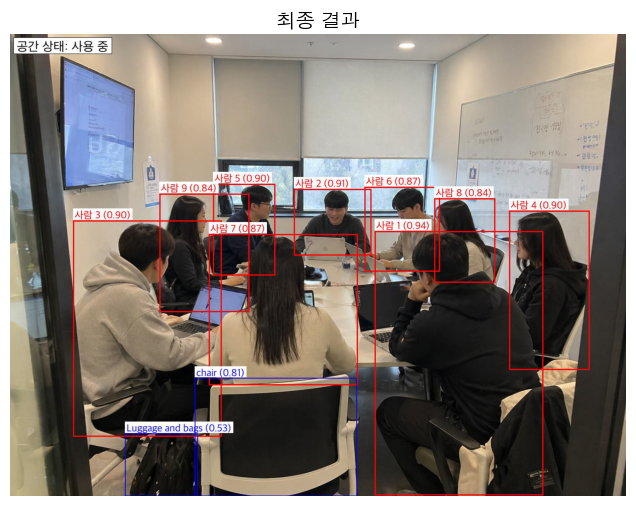

In [23]:
show_all_stage_results(stage_results)

In [24]:
print_result_metadata(result)

[분석 메타데이터]
Image height: 1086
Image width: 1448
Model version: 2023-10-01
